In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# load Dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# checking row,columns
df.shape

(891, 15)

In [7]:
# check info. about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# statistics summery
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# missing values analysis
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
# Data Cleaning
# age fill
df["age"]=df["age"].fillna(df["age"].median())

In [11]:
# embark_town fill
df["embark_town"]=df["embark_town"].fillna(df["embark_town"].mode()[0])      

In [12]:
# embarked fill
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [13]:
# deck remove
df=df.drop("deck",axis=1)

In [14]:
# again check 
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

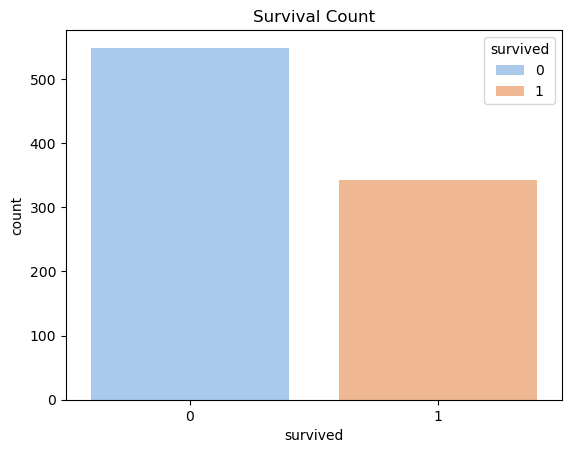

In [15]:
# survival_distribution
sns.countplot(x="survived", data=df, hue="survived", palette="pastel")
plt.title("Survival Count")
plt.show()
# most passengers did not survive the disaster. The mortality rate was higher than survival rate.

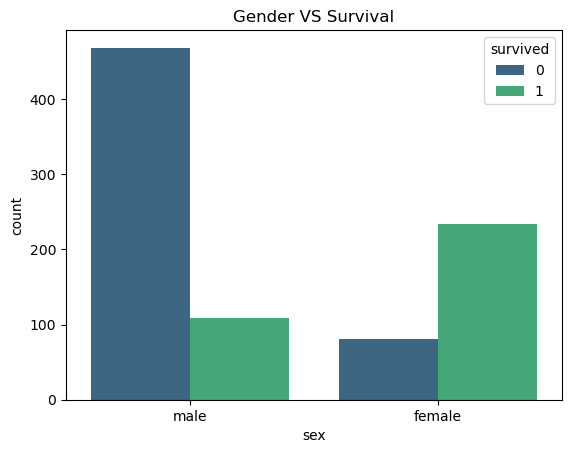

In [16]:
# gender vs survival
sns.countplot(x="sex", hue="survived", data=df, palette="viridis")
plt.title("Gender VS Survival")
plt.show()
# Female passengers had a significantly higer survival rate than male.

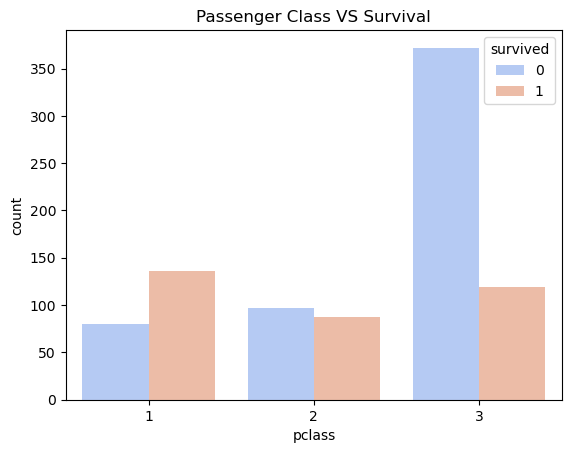

In [38]:
# passenger class vs survival
sns.countplot(x="pclass", hue="survived", data=df, palette="coolwarm")
plt.title("Passenger Class VS Survival")
plt.show()
# First-class passengers were more likely to survive, while third-class passengers faced the highest morality.

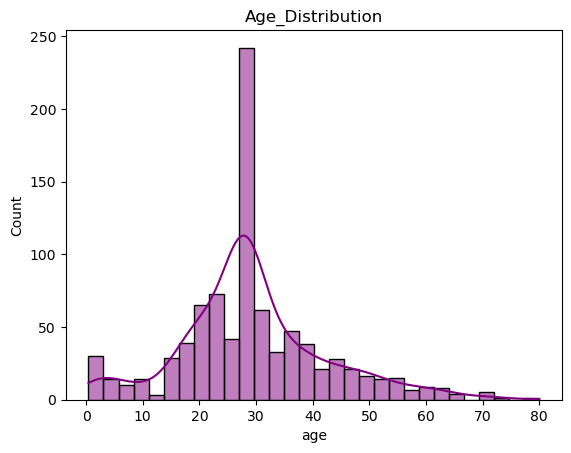

In [39]:
# age_distribution
sns.histplot(df["age"], kde=True, color="purple")
plt.title("Age_Distribution")
plt.show()
# Most passengers were young adults, with fewer elderly passengers  on board.

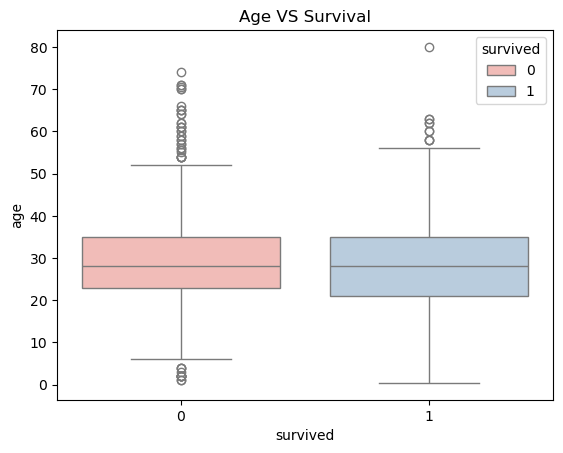

In [28]:
# age vs survival
sns.boxplot(x="survived", y="age", data=df, hue="survived", palette="Pastel1")
plt.title("Age VS Survival")
plt.show()
# Younger paseengers showed slightly better survival chances compared to older passengers.

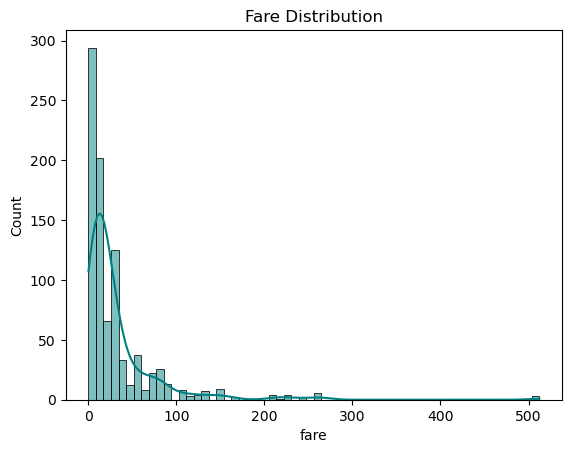

In [40]:
# fare_analysis
sns.histplot(df["fare"], kde=True, color="teal")
plt.title("Fare Distribution")
plt.show()
# Most passengers purchased lower price tickets, with only a few paying very high fares.

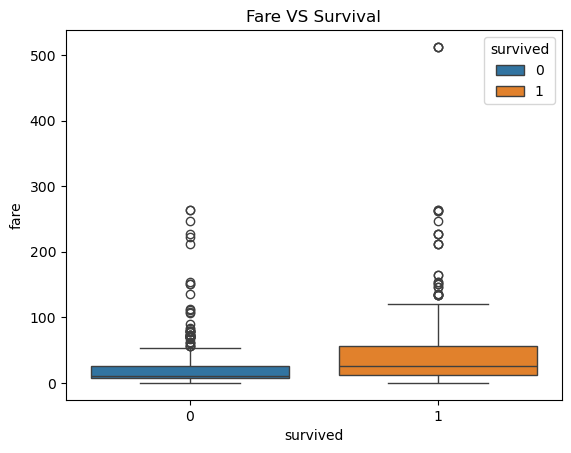

In [46]:
# fare vs survival
sns.boxplot(x="survived", y="fare", data=df, hue="survived")
plt.title("Fare VS Survival")
plt.show()
# Passengers who paid higher fares generally had better survival outcomes.

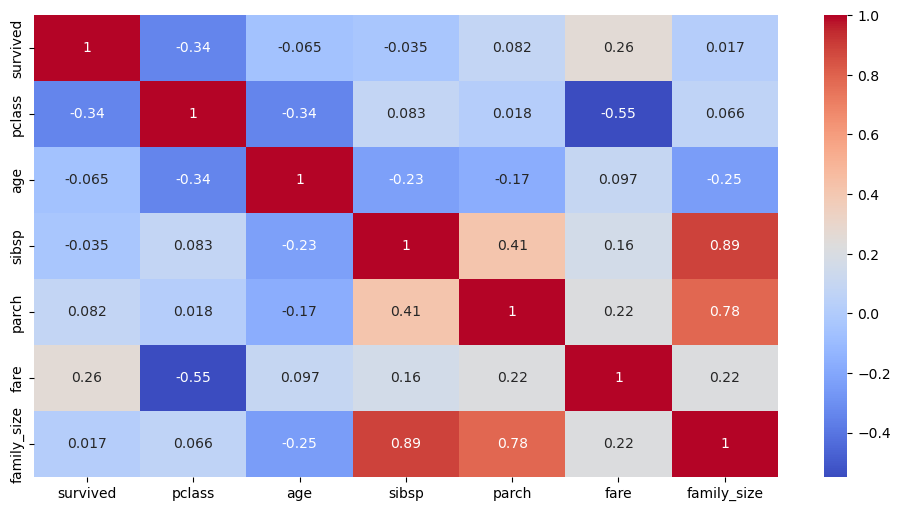

In [47]:
# correlation heatmap
numeric_df=df.select_dtypes(include=["number"])
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()
# Paseenger class and fare showed the strongest relationship with survival among numerical features.

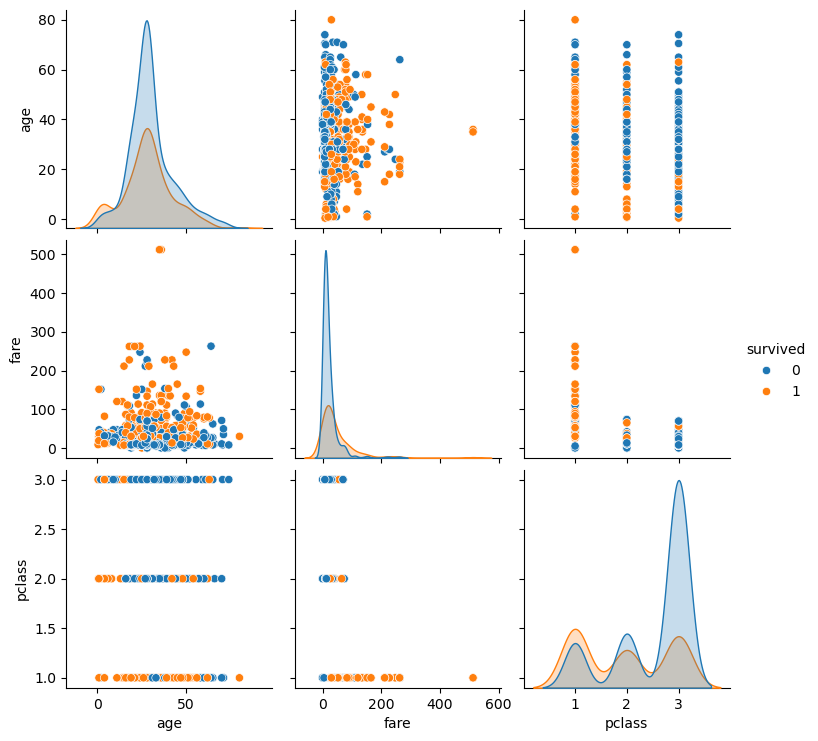

In [48]:
# pairplot
sns.pairplot(df[["survived", "age", "fare", "pclass"]], hue="survived")
plt.show()
# Survival patterns varied noticeably across fare and passenger class, indicating their importance.

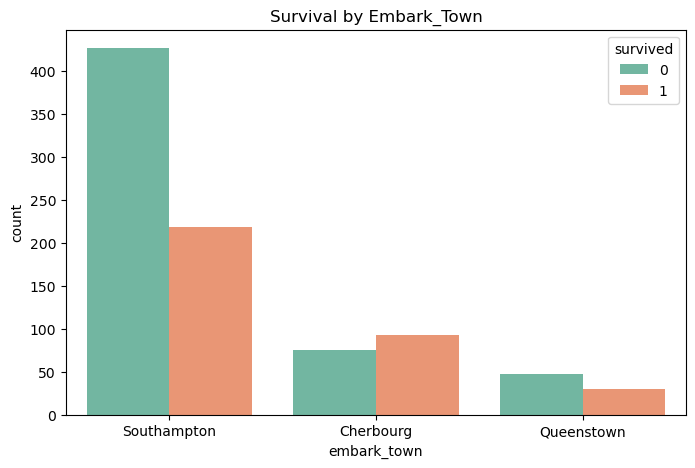

In [36]:
# survival rate by embark_town
plt.figure(figsize=(8,5))
sns.countplot(x="embark_town", hue="survived", data=df, palette="Set2")
plt.title("Survival by Embark_Town")
plt.show()
# Survival rates differed across embarkation towns, suggesting location-based passengers differences.

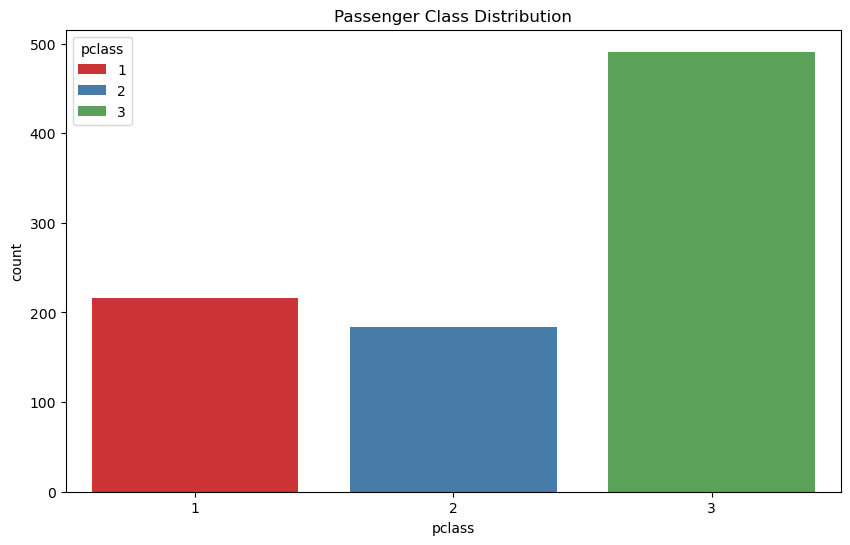

In [37]:
# passenger class distribution
plt.figure(figsize=(10,6))
sns.countplot(x="pclass", data=df, hue="pclass", palette="Set1")
plt.title("Passenger Class Distribution")
plt.show()
# The majority of passengers traveled in Third Class, indicating that lower-class travelers made up the largest portion of the Titanic's population. 

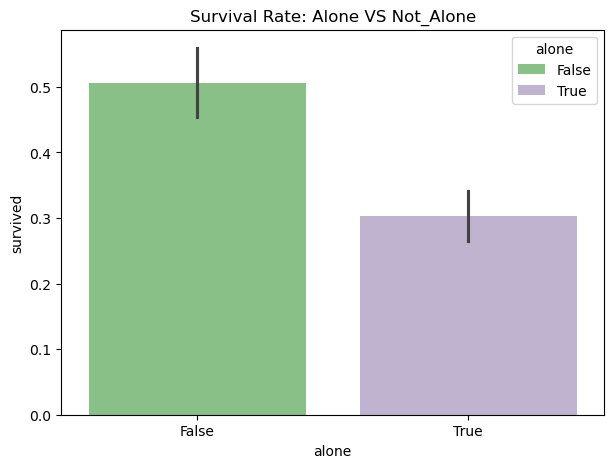

In [33]:
# survival rate by alone
plt.figure(figsize=(7,5))
sns.barplot(x="alone", y="survived", data=df, hue="alone", palette="Accent")
plt.title("Survival Rate: Alone VS Not_Alone")
plt.show() 
# paseengers travelling with family generally had higher survival rates than those travelling alone.

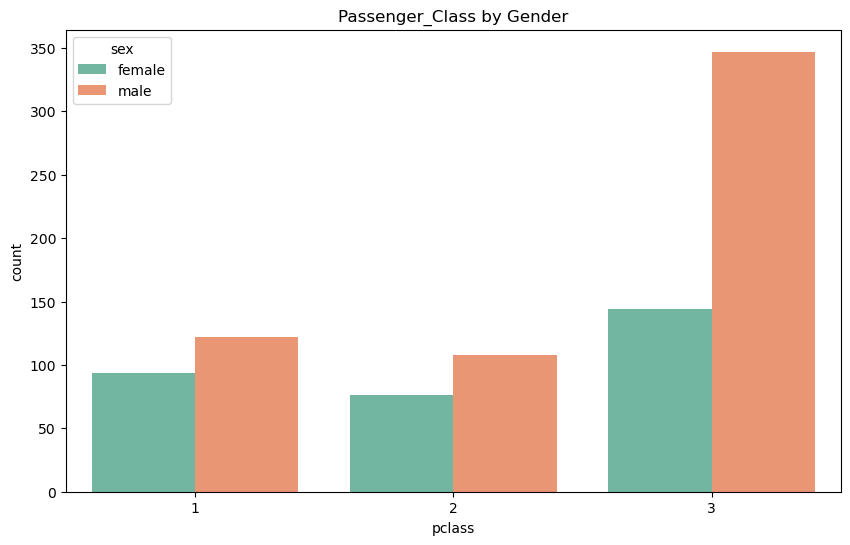

In [35]:
# passenger class and gender combined
plt.figure(figsize=(10,6))
sns.countplot(x="pclass", hue="sex", data=df, palette="Set2")
plt.title("Passenger_Class by Gender")
plt.show()
# Male passengers were more numerous across all classes, particullarly in third class.

In [ ]:
# Overall Project Conclusion
# The analysis revealed that....
# Passenger class, gender, and ticket fare were the key factors influencing survival. 
# Female and first-class passengers had the highest chances of surviavl during the Titanic disaster.